> Add tools 공식 문서: <https://langchain-ai.github.io/langgraph/tutorials/get-started/2-add-tools/>

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph.message import add_messages

# 상태 정의
class State(TypedDict):	
    messages: Annotated[list[str], add_messages]

In [3]:
from langgraph.graph import StateGraph

# 그래프 구성
graph_builder = StateGraph(State)

In [4]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

ModuleNotFoundError: No module named 'pytz'

In [13]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "부산"})

'Asia/Seoul (부산) 현재시각 2025-09-18 11:03:30'

In [14]:
query = "2025년 KT 소액결제 사건의 원인은?"

In [15]:
tools[1].invoke({"query": query, "search_period": "m"})


-------- WEB SEARCH --------
2025년 KT 소액결제 사건의 원인은?
m
1. snippet: Sep 11, 2025 · 2025년 8월 수도권에서 발생한 KT 소액결제 해킹 사건은 불법 초소형 기지국을 통한 역대급 해킹 피해 사례입니다. 피해 현황, 해킹 원인, KT 및 정부 대응, 보상 절차와 예방법까지 한눈에 정리했습니다. 2025년 8월 말부터 수도권 일부 지역을 중심으로 KT 및 KT 망을 사용하는 알뜰폰 고객들에게 휴대폰 ..., title: KT 소액결제 해킹 사건 정리 (2025) – 피해 현황·원인·보상 절차 완벽..., link: https://reasonablegift.tistory.com/175
2. snippet: 1 day ago · 경찰이 KT 무단 소액결제 사건의 용의자 2명을 체포했지만 KT 는 사건이 당초 알려진 것보다 수 주일 이전부터 발생한 것으로 뒤늦게 드러나 새 ..., title: '소액결제 범인 검거'에도 KT 초기대응 실패... 사건은 8월부터 | 한..., link: https://www.hankookilbo.com/News/Read/A2025091716260000679
3. snippet: Sep 8, 2025 · 1. 개요 [편집] 2025년 8월 말 수도권 지역에서 KT 통신사 고객의 휴대전화 무단 소액결제 피해가 발생한 사건., title: KT 소액결제 해킹 사건 - 나무위키, link: https://namu.wiki/w/KT+소액결제+해킹+사건
4. snippet: 1 day ago · 8월 5일 첫 발생 후 갈수록 늘어 KT “사전 확인·조치 못 해 송구”, KT 무단 소액결제 사태가 최소 지난달 초부터 이어져 온 것으로 나타났다. 초기에 KT 가 적극적으로 대응하지 않아 피해가 커진 게 아니냐는 지적이 나온다. 17일 국회 과학기술정보방송통신위원회 소속 황정아 더불어..., title: KT 소액결제, 한 달 전부터 ‘이상 신호’ | 서울신문, link: https://ww

"snippet: Sep 11, 2025 · 2025년 8월 수도권에서 발생한 KT 소액결제 해킹 사건은 불법 초소형 기지국을 통한 역대급 해킹 피해 사례입니다. 피해 현황, 해킹 원인, KT 및 정부 대응, 보상 절차와 예방법까지 한눈에 정리했습니다. 2025년 8월 말부터 수도권 일부 지역을 중심으로 KT 및 KT 망을 사용하는 알뜰폰 고객들에게 휴대폰 ..., title: KT 소액결제 해킹 사건 정리 (2025) – 피해 현황·원인·보상 절차 완벽..., link: https://reasonablegift.tistory.com/175;\nsnippet: 1 day ago · 경찰이 KT 무단 소액결제 사건의 용의자 2명을 체포했지만 KT 는 사건이 당초 알려진 것보다 수 주일 이전부터 발생한 것으로 뒤늦게 드러나 새 ..., title: '소액결제 범인 검거'에도 KT 초기대응 실패... 사건은 8월부터 | 한..., link: https://www.hankookilbo.com/News/Read/A2025091716260000679;\nsnippet: Sep 8, 2025 · 1. 개요 [편집] 2025년 8월 말 수도권 지역에서 KT 통신사 고객의 휴대전화 무단 소액결제 피해가 발생한 사건., title: KT 소액결제 해킹 사건 - 나무위키, link: https://namu.wiki/w/KT+소액결제+해킹+사건;\nsnippet: 1 day ago · 8월 5일 첫 발생 후 갈수록 늘어 KT “사전 확인·조치 못 해 송구”, KT 무단 소액결제 사태가 최소 지난달 초부터 이어져 온 것으로 나타났다. 초기에 KT 가 적극적으로 대응하지 않아 피해가 커진 게 아니냐는 지적이 나온다. 17일 국회 과학기술정보방송통신위원회 소속 황정아 더불어..., title: KT 소액결제, 한 달 전부터 ‘이상 신호’ | 서울신문, link: https://www1.seoul.co.kr/news/economy/industry/2025/09/18/202509180160

In [16]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x0000014EB2808360>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x0000014EB2808400>


In [17]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [18]:
tools

[StructuredTool(name='get_current_time', description='현재 시각을 반환하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x0000014EB2808360>),
 StructuredTool(name='get_web_search', description='웹 검색을 수행하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_web_search'>, func=<function get_web_search at 0x0000014EB2808400>)]

In [ ]:
from pprint import pprint

# * 딕셔너리 컴프리헨션(Dictionary Comprehension)
# - 키(Key): tool.name은 현재 순회 중인 StructuredTool 객체의 name 속성 값을 추출하여 딕셔너리의 키로 사용한다.
# - 값(Value): tool은 현재 순회 중인 StructuredTool 객체 자체를 딕셔너리의 값으로 사용한다.
pprint({tool.name: tool for tool in tools}) 

{'get_current_time': StructuredTool(name='get_current_time', description='현재 시각을 반환하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x0000014EB2808360>),
 'get_web_search': StructuredTool(name='get_web_search', description='웹 검색을 수행하는 함수.', args_schema=<class 'langchain_core.utils.pydantic.get_web_search'>, func=<function get_web_search at 0x0000014EB2808400>)}


In [ ]:
# * 왈러스(walrus) 연산자
# - 바다코끼리 닮아서 붙여진 이름
# - Python 3.8부터 도입된 문법
# - 일반적인 할당 연산자 (=)가 문(statement)인 반면, 왈러스 연산자는 식(expression)
# - 변수에 값을 할당하면서 동시에 그 값에 대한 참/거짓을 판별
dic = {"messages": ["a", "b"]}
if var := dic.get("messages"):
    print(var)

['a', 'b']


In [21]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    """

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools} # 딕셔너리 컴프리헨션(Dictionary Comprehension)

    def __call__(self, inputs: dict):
        # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
        if messages := inputs.get("messages", []): # 왈러스(walrus) 연산자 사용
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

In [ ]:
# * Case1
tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [ ]:
# * Case2
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `tools` already present.

In [23]:
from langgraph.graph import StateGraph, START, END

def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 END로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
        
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [24]:
graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")

In [25]:
graph = graph_builder.compile()

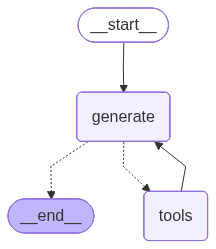

In [26]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [27]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 부산 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

지금 부산은 2025년 9월 18일 11시 05분 53초입니다.


In [28]:
gathered

AIMessageChunk(content='지금 부산은 2025년 9월 18일 11시 05분 53초입니다.\n', additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}'}}, response_metadata={'finish_reason': 'STOPSTOP', 'model_name': 'gemini-2.0-flashgemini-2.0-flash', 'safety_ratings': []}, id='run--faa55bb2-2c31-4032-948e-3cb5e4f18927', tool_calls=[{'name': 'get_current_time', 'args': {'location': '부산', 'timezone': 'Asia/Seoul'}, 'id': 'ce51557a-44d5-45da-b9e7-ee58f3e89b1a', 'type': 'tool_call'}], usage_metadata={'input_tokens': 152, 'output_tokens': 45, 'total_tokens': 254, 'input_token_details': {'cache_read': 0}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}', 'id': 'ce51557a-44d5-45da-b9e7-ee58f3e89b1a', 'index': None, 'type': 'tool_call_chunk'}])

In [29]:
from langchain_core.messages import AIMessageChunk, SystemMessage

inputs = [
    SystemMessage(content=f"""
        너는 신문기자이다. 
        최근 {query}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.
    """),
    HumanMessage(content="""
        - 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
        - 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
        - 검색할 리스트를 토대로 재검색을 한다. 
        - 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
        - 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 
        
        더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
        제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
    """)
]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        # print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg


-------- WEB SEARCH --------
2025년 KT 소액결제
3개월
1. snippet: 16분 전 — 2025년 8월부터 수도권 일부 지역에서 불법 초소형 기지국을 이용해 KT 와 KT 망 알뜰폰 등 KT 이동통신망 이용 고객의 휴대전화에서 이용한 적 없는 휴대폰 소액결제 가 ..., title: KT 고객 무단 소액결제 침해 사고, link: https://namu.wiki/w/KT+고객+무단+소액결제+침해+사고
2. snippet: 17시간 전 — KT 소액결제 사건 40대 중국교포 용의자 ... ' KT 소액결제 ' 사건 40대 중국교포 용의자 인천공항서 검거. 2025년 9월 16일 인천국제공항에서 KT 휴대전화 소액결제 피해 사건의 핵심 용의자인 중국인 A씨가 경찰에 붙잡혔다., title: 'KT 소액결제' 사건 40대 중국교포 용의자 인천공항서 검거, link: https://www.chosun.com/national/national_general/2025/09/17/VJP5RCGF5ZG4NNLLBWBPF23SRU/
3. snippet: 2시간 전 — KT 무단 소액결제 사건의 피의자가 18일 법원으로 이동하면서 다른 조력자가 있는지 등을 묻는 취재진의 질문에 묵묵부답으로 일관했다. KT 이용자들의 ..., title: 'KT 소액결제' 40대 피의자들, 조력자 여부 등 질문에 묵묵부답, link: https://www.yna.co.kr/view/AKR20250918037000061
4. snippet: Sep 11, 2025 · 2025년 8월 수도권에서 발생한 KT 소액결제 해킹 사건은 불법 초소형 기지국을 통한 역대급 해킹 피해 사례입니다. 피해 현황, 해킹 원인, KT 및 정부 대응, 보상 절차와 예방법까지 한눈에 정리했습니다. 2025년 8월 말부터 수도권 일부 지역을 중심으로 KT 및 KT 망을 사용하는 알뜰폰 고객들에게 휴대폰 ..., title: KT 소액결제 해킹 사건 정리 (2025) – 피해 현황·원인·보상 

In [30]:
gathered

AIMessageChunk(content='알겠습니다. 2025년 KT 소액결제 사건에 대한 심층 분석 기사를 작성하기 위해 다음과 같은 단계를 따르겠습니다.\n\n**1. 최신 이슈 검색 및 주제 선정:**\n\n먼저, 최근 이슈를 파악하기 위해 웹 검색을 수행하겠습니다.\n\n최근 2025년 8월에 발생한 KT 소액결제 해킹 사건은 불법 초소형 기지국을 이용한 역대급 해킹 피해 사례로, 많은 사람들의 관심이 높습니다. 이 사건은 KT와 KT 망을 사용하는 알뜰폰 고객들에게 큰 피해를 입혔으며, 개인 정보 유출 및 금전적 피해에 대한 우려를 낳았습니다. 따라서, 이 사건의 원인을 심층적으로 분석하고 비판하는 기사를 작성하는 것은 매우 중요하다고 판단했습니다.\n\n**목차**\n\n1.  **머리말**: 2025년 KT 소액결제 사건 발생 및 개요\n2.  **사건의 전개**:\n    *   2025년 8월, 수도권 중심으로 KT 소액결제 피해 발생\n    *   불법 초소형 기지국 이용, 개인 정보 탈취 및 소액결제 악용\n    *   피해 규모 및 현황 (KT 공식 발표, 언론 보도 종합)\n3.  **KT의 대응**:\n    *   사건 인지 및 초기 대응\n    *   피해 고객 보상 및 지원 대책\n    *   재발 방지 대책 발표\n    *   KT의 대응에 대한 비판적 시각 (늑장 대응, 미흡한 보상 등)\n4.  **사이버 보안 문제점**:\n    *   초소형 기지국 해킹의 기술적 원리 및 위험성\n    *   KT의 보안 시스템 취약점 분석\n    *   국내 통신사 전반의 사이버 보안 문제점 지적\n5.  **정부의 역할과 책임**:\n    *   사이버 보안 관련 법규 및 규제 현황\n    *   정부의 감독 및 관리 책임\n    *   사이버 보안 강화 위한 정책 제언\n6.  **결론**: 2025년 KT 소액결제 사건의 교훈 및 향후 과제\n\n**추가 검색 내용**\n\n1.  초소형 기지국 해킹 기술의 구

In [31]:
print(gathered.content)

알겠습니다. 2025년 KT 소액결제 사건에 대한 심층 분석 기사를 작성하기 위해 다음과 같은 단계를 따르겠습니다.

**1. 최신 이슈 검색 및 주제 선정:**

먼저, 최근 이슈를 파악하기 위해 웹 검색을 수행하겠습니다.

최근 2025년 8월에 발생한 KT 소액결제 해킹 사건은 불법 초소형 기지국을 이용한 역대급 해킹 피해 사례로, 많은 사람들의 관심이 높습니다. 이 사건은 KT와 KT 망을 사용하는 알뜰폰 고객들에게 큰 피해를 입혔으며, 개인 정보 유출 및 금전적 피해에 대한 우려를 낳았습니다. 따라서, 이 사건의 원인을 심층적으로 분석하고 비판하는 기사를 작성하는 것은 매우 중요하다고 판단했습니다.

**목차**

1.  **머리말**: 2025년 KT 소액결제 사건 발생 및 개요
2.  **사건의 전개**:
    *   2025년 8월, 수도권 중심으로 KT 소액결제 피해 발생
    *   불법 초소형 기지국 이용, 개인 정보 탈취 및 소액결제 악용
    *   피해 규모 및 현황 (KT 공식 발표, 언론 보도 종합)
3.  **KT의 대응**:
    *   사건 인지 및 초기 대응
    *   피해 고객 보상 및 지원 대책
    *   재발 방지 대책 발표
    *   KT의 대응에 대한 비판적 시각 (늑장 대응, 미흡한 보상 등)
4.  **사이버 보안 문제점**:
    *   초소형 기지국 해킹의 기술적 원리 및 위험성
    *   KT의 보안 시스템 취약점 분석
    *   국내 통신사 전반의 사이버 보안 문제점 지적
5.  **정부의 역할과 책임**:
    *   사이버 보안 관련 법규 및 규제 현황
    *   정부의 감독 및 관리 책임
    *   사이버 보안 강화 위한 정책 제언
6.  **결론**: 2025년 KT 소액결제 사건의 교훈 및 향후 과제

**추가 검색 내용**

1.  초소형 기지국 해킹 기술의 구체적인 작동 방식
2.  KT의 보안 시스템 취약점에 대한 기술적 분석 (보안 전문가 인터뷰)
3. 